# Bird Species Image Classification — Traditional CNN (Built From Scratch)

**Goal:** Same task as before — classify bird photos by species — but this time we build a
**Convolutional Neural Network (CNN) completely from scratch**, instead of reusing a pretrained
model like MobileNetV2.

**Why build one from scratch?** In the previous notebook we used *transfer learning*, which reused
knowledge from a model already trained on 1.4 million images. In this notebook, every single weight
in the network starts out random and the model has to learn everything — edges, shapes, colors,
feather patterns, and finally the species themselves — using only our own dataset. This is called a
"traditional" deep learning approach, and it's important to understand it because it's the foundation
that transfer learning is built on top of.

**Trade-off to expect:** Because our bird dataset is fairly small (a few hundred images per species),
a from-scratch CNN will typically get **lower accuracy** than the transfer learning version, and it
may take longer to train. This is completely normal and expected — it's actually a good learning
exercise to compare both notebooks side by side and see the difference transfer learning makes.

**Model architecture we will use:** A classic, beginner-friendly CNN made of repeating blocks of:

`Convolution -> Activation -> Pooling`

stacked a few times, followed by `Flatten -> Dense -> Dropout -> Dense (output)`. This is the
traditional architecture style popularized by early CNNs like LeNet and VGG, and it is well suited
to image classification problems like this one.

As with the previous notebook, every cell has a short explanation above it and comments inside the
code, kept as beginner-friendly as possible.

## Step 1: Import the Libraries

- `os` and `pathlib` — for working with folders and file paths.
- `numpy` — for numerical operations.
- `matplotlib.pyplot` — for plotting images and graphs.
- `tensorflow` / `keras` — the deep learning library. This time we import the basic building block
  layers (`Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout`) because we are constructing the
  whole network ourselves, layer by layer.

In [35]:
# Basic Python tools for handling files and folders
import os
from pathlib import Path

# Numerical operations
import numpy as np

# For plotting images and graphs
import matplotlib.pyplot as plt

# Deep learning library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Just to check everything installed correctly and see which TensorFlow version we have
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 2: Set the Dataset Path and Basic Parameters

Same dataset as before. A couple of settings are different this time:

- `IMG_HEIGHT`, `IMG_WIDTH` — we use a smaller image size (128x128 instead of 224x224). We are no
  longer required to match MobileNetV2's expected input size, and smaller images train noticeably
  faster, which matters more when training a network from scratch (it needs more epochs to learn).
- `EPOCHS` — we allow more epochs than the transfer learning notebook, since a from-scratch model
  needs more time to learn useful features.

**Important:** Update `DATASET_DIR` below if your folder path is different.

In [36]:
# Path to the main dataset folder (the one that contains one sub-folder per bird species).
# Update this path if your folder is located somewhere else.
DATASET_DIR = Path(r"/home/asus/projects/computer_vision/Bird species image classification/Bird Speciees Dataset")

# Image size we will resize all pictures to. Smaller than the transfer-learning notebook (224x224)
# because training from scratch is more computationally expensive, and 128x128 is still plenty of
# detail for a CNN to learn distinguishing bird features.
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# How many images are shown to the model at once during training
BATCH_SIZE = 32

# A from-scratch model needs more epochs to learn compared to transfer learning,
# since it starts with random weights instead of pretrained ones.
EPOCHS = 45

# Percentage of images set aside for validation (used to check performance during training)
VALIDATION_SPLIT = 0.2

# A fixed random seed so results are reproducible (same split every time we run the notebook)
SEED = 42

## Step 3: Explore the Dataset

Same exploration as before — check how many species (classes) there are and how many images each
one has. This is worth re-running here since this notebook may be run independently from the first
one.

In [37]:
# Get the list of class (bird species) folder names automatically.
# Each folder inside DATASET_DIR represents one class/species.
class_names = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

print("Number of bird species (classes) found:", len(class_names))
print("Class names:")
for name in class_names:
    print(" -", name)

Number of bird species (classes) found: 6
Class names:
 - AMERICAN GOLDFINCH
 - BARN OWL
 - CARMINE BEE-EATER
 - DOWNY WOODPECKER
 - EMPEROR PENGUIN
 - FLAMINGO


In [38]:
# Count how many images are inside each class folder
image_counts = {}

for class_name in class_names:
    class_folder = DATASET_DIR / class_name
    num_images = len([
        f for f in class_folder.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    image_counts[class_name] = num_images

print("Number of images per species:")
for class_name, count in image_counts.items():
    print(f" - {class_name}: {count} images")

print("\nTotal images:", sum(image_counts.values()))

Number of images per species:
 - AMERICAN GOLDFINCH: 143 images
 - BARN OWL: 129 images
 - CARMINE BEE-EATER: 131 images
 - DOWNY WOODPECKER: 137 images
 - EMPEROR PENGUIN: 139 images
 - FLAMINGO: 132 images

Total images: 811


## Step 4: Visualize Sample Images

A quick visual check that the images loaded correctly, and to remind ourselves what we're working
with before we start building the model.

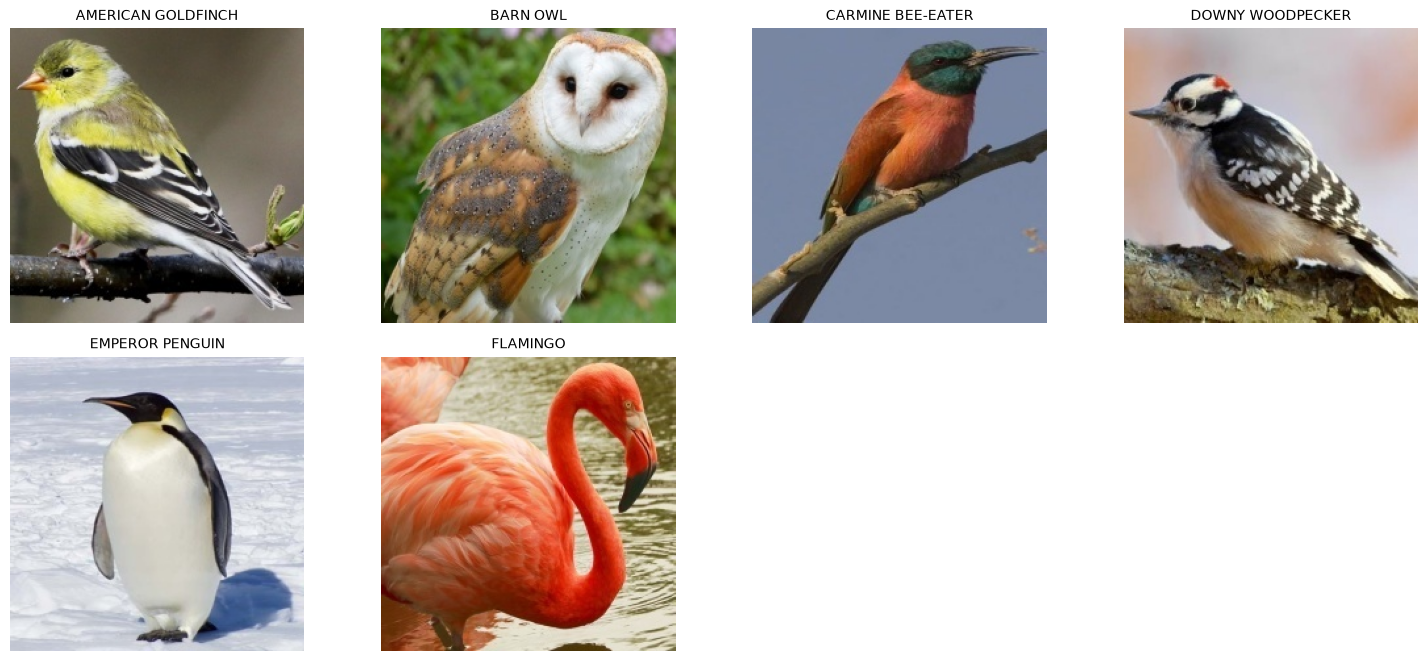

In [39]:
# Show one example image from each class in a grid
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):
    class_folder = DATASET_DIR / class_name

    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    if len(image_files) == 0:
        continue
    sample_image_path = image_files[0]

    img = keras.preprocessing.image.load_img(sample_image_path)
    plt.subplot(3, 4, i + 1)  # Adjust grid size (rows, cols) if you have more/fewer classes
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Prepare the Data for Training

Same idea as before: rescale pixel values to the 0-1 range, and use data augmentation on the
training set so the model sees more variety and doesn't just memorize the training images.

Data augmentation matters **even more** here than in the transfer learning notebook, because a
from-scratch model has no prior knowledge to fall back on — it is much more likely to overfit a
small dataset, so we lean a little more heavily on augmentation to fight that.

In [40]:
# ImageDataGenerator for the TRAINING data.
# rescale=1./255 converts pixel values from [0, 255] to [0, 1]
# The other parameters randomly modify the images slightly (data augmentation) to create more variety
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,          # randomly rotate images by up to 20 degrees
    width_shift_range=0.1,     # randomly shift images horizontally
    height_shift_range=0.1,    # randomly shift images vertically
    zoom_range=0.1,             # randomly zoom into images
    brightness_range=(0.8, 1.2), # randomly change brightness
    shear_range=0.1,             # randomly apply a shearing transform
    horizontal_flip=True,        # randomly flip images left-right
    validation_split=VALIDATION_SPLIT  # reserve part of the data for validation
)

# ImageDataGenerator for VALIDATION data — only rescaling, no augmentation.
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VALIDATION_SPLIT
)

In [41]:
# Automatically find all images inside DATASET_DIR, resize them, and assign labels
# based on their folder name. subset="training" picks 80% of the data for training.
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # because we have more than 2 classes
    subset="training",
    seed=SEED
)

# subset="validation" picks the remaining 20% of the data for validation.
validation_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

print("Class indices used by the model:", train_generator.class_indices)

Found 652 images belonging to 6 classes.
Found 159 images belonging to 6 classes.
Class indices used by the model: {'AMERICAN GOLDFINCH': 0, 'BARN OWL': 1, 'CARMINE BEE-EATER': 2, 'DOWNY WOODPECKER': 3, 'EMPEROR PENGUIN': 4, 'FLAMINGO': 5}


## Step 6: Build a Convolutional Neural Network From Scratch

Unlike the transfer learning notebook, there is no pretrained base model here — every layer below
starts with random weights and learns purely from our bird images.

We build the network as a **stack of repeating blocks**, where each block usually contains:

1. **`Conv2D`** — slides small filters (e.g. 3x3) across the image to detect patterns such as edges,
   colors, and textures. Each filter learns to detect a different pattern. Early layers learn simple
   patterns (edges, blobs of color); deeper layers combine those into more complex patterns
   (feathers, beaks, eye shapes).
2. **`BatchNormalization`** — normalizes the outputs of the convolution to keep training stable and
   faster, especially useful when training a deep network from scratch.
3. **`MaxPooling2D`** — shrinks the image size by keeping only the strongest signal in each small
   region. This reduces computation and helps the network focus on "was this pattern present"
   rather than "exactly where was this pattern".
4. **`Dropout`** — randomly turns off some neurons during training to reduce overfitting, which
   matters a lot here since we have a relatively small dataset and no pretrained knowledge to rely on.

We repeat this block a few times, each time using **more filters** (32 -> 64 -> 128 -> 128), because
deeper layers need to represent more complex, more varied patterns and therefore benefit from more
filters.

After the convolutional blocks, we `Flatten` the resulting 3D block into a 1D vector (similar in
spirit to `GlobalAveragePooling2D` from the previous notebook, but simpler — it just lines up every
number in a row instead of averaging), then pass it through a couple of `Dense` layers to make the
final species prediction.

In [42]:
model = Sequential([

    # --- Block 1 ---
    # 32 filters of size 3x3 slide over the image looking for simple patterns (edges, colors)
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),          # stabilizes and speeds up training
    MaxPooling2D(pool_size=(2, 2)),  # shrinks the feature map size by half
    Dropout(0.25),                  # randomly drop 25% of values to reduce overfitting

    # --- Block 2 ---
    # More filters (64) to detect more complex combinations of patterns
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # --- Block 3 ---
    # Even more filters (128) for higher-level patterns like feather textures or beak shapes
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # --- Block 4 ---
    # Deepest convolutional block, still 128 filters, learning the most complex, most specific patterns
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    # --- Classification layers ---
    Flatten(),                              # turn the 3D feature block into a flat 1D vector
    Dense(256, activation="relu"),           # a fully-connected hidden layer that combines all features
    Dropout(0.5),                            # strong dropout here since this is the layer most prone to overfitting
    Dense(len(class_names), activation="softmax")  # output layer: one probability per bird species
])

## Step 7: Compile the Model

Same settings as the transfer learning notebook, for the same reasons:

- **`adam`** optimizer — a reliable, widely-used default for updating the model's weights.
- **`categorical_crossentropy`** loss — the standard loss function for multi-class classification.
- **`accuracy`** metric — the percentage of correctly classified images, tracked during training.

In [43]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Print a summary of the model: layers, output shapes, and number of trainable parameters.
# Compare this to the transfer learning notebook's summary — notice how ALL parameters here
# are trainable, since nothing is frozen.
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,666,566 (25.43 MB)

 Trainable params: 6,665,862 (25.43 MB)

 Non-trainable params: 704 (2.75 KB)

## Step 8: Set Up Training Callbacks

Same two callbacks as before:

- **EarlyStopping** — stops training if validation loss stops improving for a few epochs in a row,
  and restores the best weights found. This is especially useful here since a from-scratch model
  is more prone to overfitting the longer it trains.
- **ModelCheckpoint** — saves the best version of the model (by validation accuracy) to a file as
  training progresses.

In [44]:
# Stop training early if validation loss doesn't improve for 5 epochs in a row.
# We use a slightly larger patience than the transfer learning notebook, since a from-scratch
# model's validation performance can be a bit noisier early on.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Save the best model (based on validation accuracy) to a file as we train
checkpoint = ModelCheckpoint(
    "best_bird_cnn_scratch_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

## Step 9: Train the Model

This will likely take longer than the transfer learning notebook, since the network is learning
everything from scratch instead of reusing pretrained knowledge. `EarlyStopping` will stop training
automatically once the model stops improving, so it won't necessarily run the full `EPOCHS`.

In [45]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/45


I0000 00:00:1785029510.303005   21312 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18619__.79


 1/21 ━━━━━━━━━━━━━━━━━━━━ 7:40 23s/step - accuracy: 0.0938 - loss: 6.3762

I0000 00:00:1785029522.617258   21314 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18619__.79


21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4371 - loss: 10.5721 - val_accuracy: 0.1824 - val_loss: 5.4939
Epoch 2/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 546ms/step - accuracy: 0.6212 - loss: 3.5323 - val_accuracy: 0.2264 - val_loss: 6.4542
Epoch 3/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step - accuracy: 0.6764 - loss: 2.1613 - val_accuracy: 0.1572 - val_loss: 4.0344
Epoch 4/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 480ms/step - accuracy: 0.7178 - loss: 1.1920 - val_accuracy: 0.3836 - val_loss: 2.4578
Epoch 5/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.7515 - loss: 0.8063 - val_accuracy: 0.2893 - val_loss: 4.5553
Epoch 6/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 552ms/step - accuracy: 0.7500 - loss: 0.7674 - val_accuracy: 0.2390 - val_loss: 3.5782
Epoch 7/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 444ms/step - accuracy: 0.8190 - loss: 0.6463 - val_accuracy: 0.2642 - val_loss: 8.6782
Epoch 8/45
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 486ms/step - accuracy: 0.8206 - loss: 0.6015 - val_accuracy: 0.3333 -

## Step 10: Plot the Training History

Same idea as before — plotting training vs validation accuracy and loss helps us see whether the
model is learning well or overfitting.

With a from-scratch CNN, it's especially common to see the training accuracy climb much higher than
the validation accuracy — that gap is overfitting, and it's one of the clearest differences you'll
likely notice compared to the transfer learning notebook.

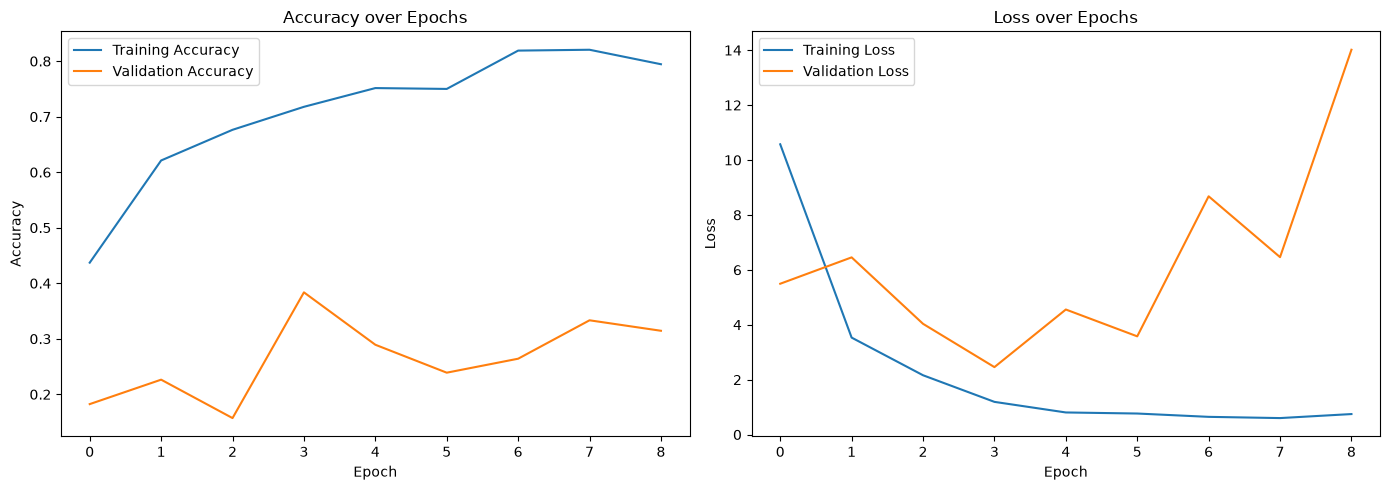

In [46]:
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 11: Evaluate the Model

Check the model's final accuracy and loss on the validation set. It's worth comparing this number
directly to the transfer learning notebook's validation accuracy to see the effect transfer learning
had.

In [47]:
val_loss, val_accuracy = model.evaluate(validation_generator)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy * 100:.2f}%)")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.3836 - loss: 2.4578
Validation Loss: 2.4578
Validation Accuracy: 0.3836 (38.36%)


## Step 12: Test the Model on Some Sample Images

Same sanity check as before — take a batch of validation images, predict their species, and compare
against the true labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


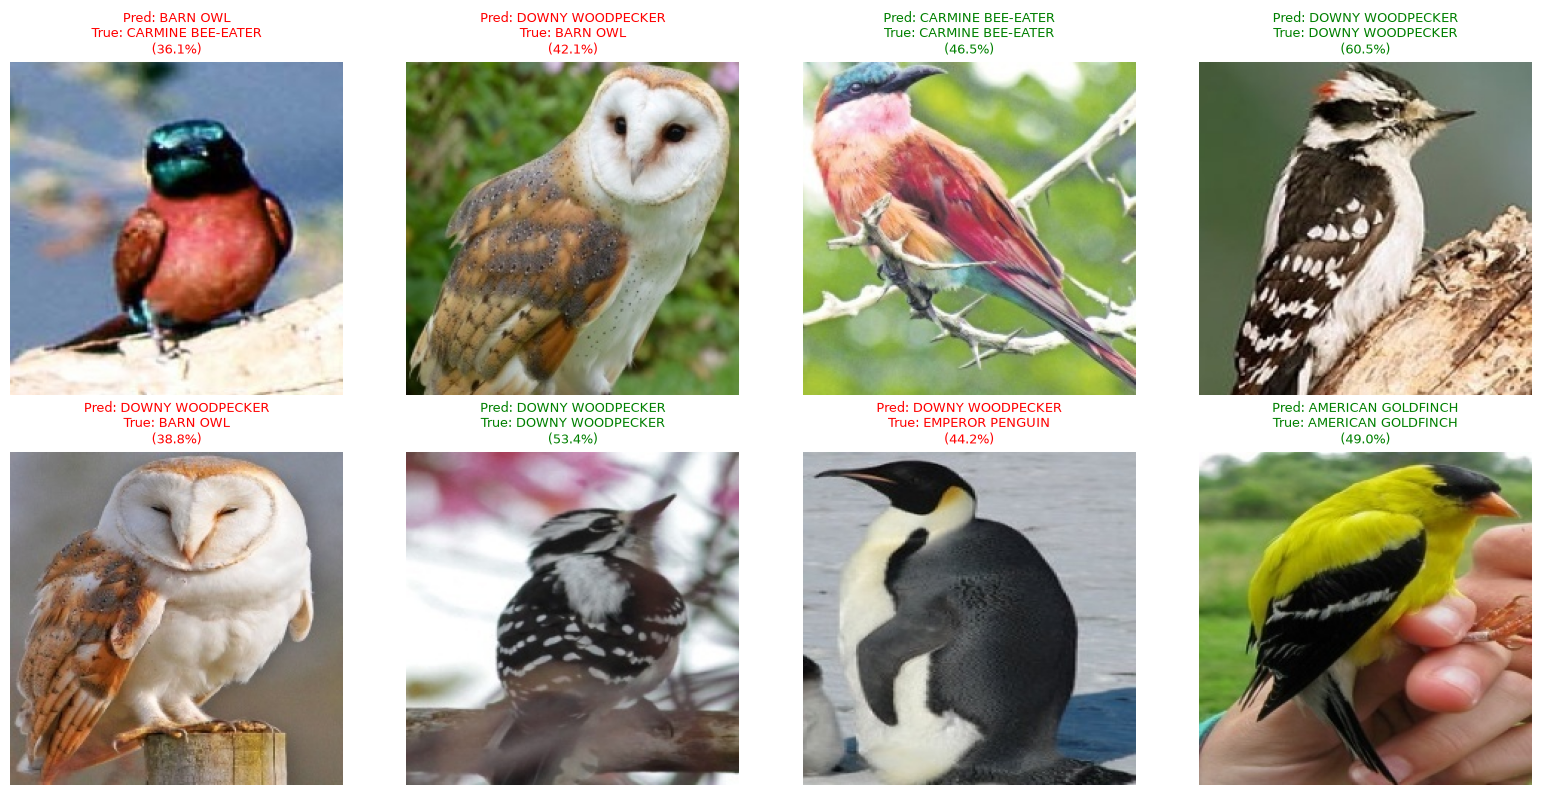

In [48]:
# Get one batch of images and their true labels from the validation generator
sample_images, sample_labels = next(validation_generator)

# Get the model's predictions for this batch
predictions = model.predict(sample_images)

# Map numeric class indices back to species names
index_to_class = {v: k for k, v in train_generator.class_indices.items()}

# Display up to 8 sample predictions
plt.figure(figsize=(16, 8))
num_to_show = min(8, len(sample_images))

for i in range(num_to_show):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])

    predicted_class = index_to_class[np.argmax(predictions[i])]
    true_class = index_to_class[np.argmax(sample_labels[i])]
    confidence = np.max(predictions[i]) * 100

    # Green title if correct, red if wrong
    color = "green" if predicted_class == true_class else "red"
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}\n({confidence:.1f}%)",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 13: Save the Final Model

Save the trained model to a file for later reuse, so it doesn't need to be retrained from scratch
every time.

In [49]:
model.save("bird_species_cnn_scratch.keras")
print("Model saved as bird_species_cnn_scratch.keras")

Model saved as bird_species_cnn_scratch.keras


## Comparing This Notebook to the Transfer Learning Notebook

Now that both notebooks are trained, it's worth comparing them directly:

| | Transfer Learning (MobileNetV2) | From-Scratch CNN (this notebook) |
|---|---|---|
| Starting weights | Pretrained on 1.4M ImageNet images | Random |
| Trainable parameters | Only the new head (small) | Every single layer (large) |
| Training speed | Faster to reach good accuracy | Slower, needs more epochs |
| Data needed | Works well even with a small dataset | Needs more data to reach the same accuracy |
| Typical accuracy on a small dataset | Usually higher | Usually lower, more prone to overfitting |

## Next Steps / Ideas to Improve This Model (Optional)

- **Add more data**: from-scratch CNNs benefit the most from having more training images.
- **Try a slightly deeper or shallower network**: experiment with adding or removing one
  convolutional block and see how it affects accuracy.
- **Adjust dropout rates**: if the model overfits a lot, try increasing dropout; if it underfits
  (both training and validation accuracy stay low), try decreasing it.
- **Learning rate tuning**: try a smaller learning rate (e.g. using
  `keras.optimizers.Adam(learning_rate=0.0005)`) if training looks unstable.